Creation of the Synthetic Dataset

In [ ]:
# 1) Imports, config, helpers
import numpy as np
import pandas as pd

# Reproducibility
np.random.seed(42)

# ---- Helper functions ----
def clamp(x, lo, hi):
    """Clip array x to [lo, hi]."""
    return np.minimum(np.maximum(x, lo), hi)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))
# Defines the sigmoid function (common in statistics/ML).
# For each value in x, computes 1 / (1 + e^(-x)).
# Outputs numbers between 0 and 1; small x → near 0, large x → near 1.


def to_ordinal_1_5(z):
    """
    Map a continuous score to ordinal 1..5 by equal-frequency binning.
    (Uses pandas.qcut to get balanced buckets.)
    """
    s = pd.qcut(pd.Series(z), 5, labels=[1,2,3,4,5])
    return np.asarray(s.astype(int))

def sample_categorical(weights, labels):
    """
    Sample from categorical distribution for each row.
    weights: shape (n, k) probabilities (need not be normalized).
    labels:  list of k category labels.
    """
    weights = np.asarray(weights, dtype=float)
    if weights.ndim == 1:
        weights = weights[None, :]
    weights = np.maximum(weights, 1e-9)
    weights = weights / weights.sum(axis=1, keepdims=True)
    cum = np.cumsum(weights, axis=1)
    r = np.random.rand(weights.shape[0], 1)
    idx = (cum < r).sum(axis=1)
    return np.array([labels[i] for i in idx])

def bernoulli(p):
    """Bernoulli draws for vector of probabilities p."""
    p = np.clip(p, 0.0, 1.0)
    return (np.random.rand(p.shape[0]) < p).astype(int)

def zscore(x):
    x = np.asarray(x, float)
    return (x - x.mean()) / (x.std() + 1e-8)


In [107]:
# 2) Config and category priors
N = 50000  

institution_types = [
    ("Bank", 0.35), ("Fintech", 0.15), ("Insurance", 0.10), ("Asset Manager", 0.10),
    ("Investment Bank", 0.08), ("Payment Processor", 0.07), ("Brokerage/Dealer", 0.06),
    ("Credit Union", 0.04), ("Hedge Fund", 0.03), ("RegTech", 0.02),
]

countries = [
    ("United States", 0.30), ("United Kingdom", 0.20),
    ("European Union", 0.30), ("Other", 0.20),
]


In [108]:
# 3) Categories
inst_labels, inst_pr = zip(*institution_types)
inst_pr = np.array(inst_pr) / np.sum(inst_pr)
institution_type = np.random.choice(inst_labels, size=N, p=inst_pr)

country_labels, country_pr = zip(*countries)
country_pr = np.array(country_pr) / np.sum(country_pr)
country = np.random.choice(country_labels, size=N, p=country_pr)

# GDPR proxy (UK/EU)
is_gdpr = np.isin(country, ["United Kingdom", "European Union"]).astype(int)


In [109]:
# 4) Latent factors (size, readiness, governance, leadership)
size_z = np.random.normal(0, 1, N)
eps1 = np.random.normal(0, 1, N)
eps2 = np.random.normal(0, 1, N)
eps3 = np.random.normal(0, 1, N)
eps4 = np.random.normal(0, 1, N)

# Correlate readiness/governance/leadership with size a bit
readiness_z  = 0.35*size_z + 0.93*eps1/np.sqrt(1+0.35**2)
governance_z = 0.25*size_z + 0.97*eps2/np.sqrt(1+0.25**2)
leadership_z = 0.20*size_z + 0.30*governance_z + 0.93*eps3/np.sqrt(1+0.2**2+0.3**2)
data_z       = 0.40*readiness_z + 0.20*leadership_z + 0.90*eps4/np.sqrt(1+0.4**2+0.2**2)


In [110]:
# 5) Size & budget variables
# Employee count (log-normal by size)
emp_log_mu = np.log(1500) + 0.60*size_z
emp_sigma  = 0.55
employee_count = np.exp(emp_log_mu + emp_sigma*np.random.normal(size=N)).astype(int)
employee_count = np.maximum(employee_count, 50)

# Annual revenue (M GBP), log-normal by size
rev_log_mu = np.log(850) + 0.70*size_z
rev_sigma  = 0.70
annual_revenue_m = np.exp(rev_log_mu + rev_sigma*np.random.normal(size=N))
annual_revenue_m = clamp(annual_revenue_m, 50, 50000)  # clamp tails

# IT spend % revenue
it_spend_pct = 4.5 + 0.7*readiness_z + 0.3*size_z + np.random.normal(0, 1.2, N)
it_spend_pct = clamp(it_spend_pct, 0, 15)

# AI budget as % revenue (primary budget intensity variable)
ai_budget_pct = 0.8 + 0.30*readiness_z + 0.25*leadership_z + 0.15*size_z + np.random.normal(0, 0.4, N)
ai_budget_pct = clamp(ai_budget_pct, 0, 5)

# AI budget allocated (M GBP) derived from % of revenue + mild noise
ai_budget_allocated = annual_revenue_m * (ai_budget_pct/100.0) * np.exp(np.random.normal(0, 0.15, N))
ai_budget_allocated = clamp(ai_budget_allocated, 0, 500_000_000/1_000_000)  # cap at £500m


In [111]:
# 6) Capability & architecture variables
budget_growth_yoy = clamp(8 + 3*leadership_z + np.random.normal(0, 6, N), -20, 60)

has_ai_team = bernoulli(sigmoid(-0.2 + 0.5*readiness_z + 0.3*size_z))

tech_readiness = clamp(60 + 15*readiness_z + 5*has_ai_team + np.random.normal(0, 10, N), 0, 100)

legacy_score = clamp(55 - 10*readiness_z - 6*size_z + np.random.normal(0, 12, N), 0, 100)

api_integration = clamp(58 + 15*readiness_z - 0.30*legacy_score + np.random.normal(0, 10, N), 0, 100)

data_maturity = clamp(sigmoid(1.0*readiness_z + 0.5*leadership_z + 0.1*size_z + np.random.normal(0, 0.7, N)), 0, 1)

data_lake_exists = bernoulli(sigmoid(-0.1 + 1.0*readiness_z + 0.5*leadership_z))


In [112]:
# 7) Governance, risk & culture
gov_framework_exists = bernoulli(sigmoid(0.2 + 0.9*governance_z))

governance_maturity = to_ordinal_1_5(0.1 + 0.9*governance_z + 0.2*size_z + np.random.normal(0, 0.5, N))

ai_governance_committee = bernoulli(sigmoid(-0.1 + 0.8*governance_z + 0.2*size_z))

model_risk_mgmt_maturity = to_ordinal_1_5(0.0 + 0.8*governance_z + 0.1*size_z + np.random.normal(0, 0.6, N))

# Zero-inflated Poisson for compliance incidents
lam = np.exp(0.3 - 0.6*governance_z + 0.2*size_z)
extra_zero = bernoulli(0.55*np.ones(N))
compliance_incidents = np.random.poisson(lam).astype(int)
compliance_incidents[extra_zero == 1] = 0
compliance_incidents = clamp(compliance_incidents, 0, 20).astype(int)

risk_culture_score = to_ordinal_1_5(0.0 + 0.7*governance_z + np.random.normal(0, 0.7, N))

data_privacy_compliant = bernoulli(clamp(0.50 + 0.15*is_gdpr + 0.15*sigmoid(governance_z), 0, 1))

cybersecurity_level = to_ordinal_1_5(0.2*size_z + 0.5*readiness_z + np.random.normal(0, 0.8, N))


In [113]:
# 8) Leadership, skills & strategy
leadership_commitment = to_ordinal_1_5(leadership_z + np.random.normal(0, 0.5, N))

train_log_mu = np.log(800) + 0.20*leadership_z + 0.10*readiness_z
train_sigma  = 0.55
training_investment_per_emp = np.exp(train_log_mu + train_sigma*np.random.normal(size=N))
training_investment_per_emp = clamp(training_investment_per_emp, 0, 5000)

# Vendor strategy via softmax over logits
w_inhouse = -0.3 + 0.5*size_z + 0.4*readiness_z + 0.3*(ai_budget_pct - ai_budget_pct.mean())
w_vendor  =  0.4 - 0.3*size_z - 0.2*readiness_z - 0.2*(ai_budget_pct - ai_budget_pct.mean())
w_hybrid  =  0.1 + 0.1*np.random.normal(size=N)
W = np.vstack([w_inhouse, w_hybrid, w_vendor]).T
W_exp = np.exp(W - W.max(axis=1, keepdims=True))
W_prob = W_exp / W_exp.sum(axis=1, keepdims=True)
vendor_strategy = sample_categorical(W_prob, ["In-house","Hybrid","Vendor"])

# Deployment mode (GDPR -> more Private/On-Prem)
w_onprem  =  0.3*is_gdpr + 0.2*(1 - data_privacy_compliant) + 0.1*np.random.normal(size=N)
w_privcld =  0.6*is_gdpr + 0.2*data_privacy_compliant + 0.1*readiness_z
w_pubcld  =  0.7*(1 - is_gdpr) + 0.1*readiness_z + 0.1*np.random.normal(size=N)
W2 = np.vstack([w_onprem, w_privcld, w_pubcld]).T
W2_exp = np.exp(W2 - W2.max(axis=1, keepdims=True))
W2_prob = W2_exp / W2_exp.sum(axis=1, keepdims=True)
deployment_mode = sample_categorical(W2_prob, ["On-Prem","PrivateCloud","PublicCloud"])

# Experience & pilots
existing_ai_projects = np.random.poisson(np.exp(1.3 + 0.5*readiness_z + 0.2*size_z)).astype(int)
existing_ai_projects = clamp(existing_ai_projects, 0, 50).astype(int)

use_case_breadth = np.random.poisson(np.exp(0.8 + 0.4*readiness_z + 0.2*leadership_z)).astype(int)
use_case_breadth = clamp(use_case_breadth, 0, 15).astype(int)


In [114]:
# 9) Target: LLM_Adoption_Status (logistic with calibrated intercept)
z_ai_pct   = zscore(ai_budget_pct)
z_tr       = zscore(tech_readiness)
z_gov_mat  = zscore(governance_maturity)
z_data_mat = zscore(data_maturity)
z_api      = zscore(api_integration)
z_legacy   = zscore(legacy_score)
z_leader   = zscore(leadership_commitment)
z_comp     = zscore(compliance_incidents)

interaction_tr_gov = z_tr * z_gov_mat

base_logit = (
    1.6*z_ai_pct
  + 1.4*z_tr
  + 0.6*z_gov_mat
  + 0.8*interaction_tr_gov
  + 0.4*z_data_mat
  + 0.3*z_api
  - 0.4*z_legacy
  + 0.3*z_leader
  - 0.3*z_comp
  + 0.25*data_privacy_compliant
)

# Small compliance bump for GDPR + Private/On-Prem
bump = ((is_gdpr==1) & np.isin(deployment_mode, ["PrivateCloud","On-Prem"])).astype(int) * 0.15
base_logit = base_logit + bump

# Calibrate intercept by bisection to get mean adoption ≈ 0.30
target = 0.30
lo, hi = -10.0, 10.0
for _ in range(80):
    mid = 0.5*(lo+hi)
    m = sigmoid(base_logit + mid).mean()
    if m > target:
        hi = mid
    else:
        lo = mid
c = 0.5*(lo+hi)

p_adopt = sigmoid(base_logit + c)
llm_adoption_status = bernoulli(p_adopt)
print("Calibrated adoption rate:", p_adopt.mean())


Calibrated adoption rate: 0.30000000000000004


In [115]:
# 10) Assemble and save
df = pd.DataFrame({
    "Institution_ID": np.arange(1, N+1, dtype=int),
    "Institution_Type": institution_type,
    "Country": country,
    "Employee_Count": employee_count.astype(int),
    "Annual_Revenue_M": np.round(annual_revenue_m, 2),
    "IT_Spend_Percent_Revenue": np.round(it_spend_pct, 2),
    "AI_Budget_Allocated": np.round(ai_budget_allocated, 2),        # in millions GBP
    "AI_Budget_Percent_Revenue": np.round(ai_budget_pct, 3),
    "Budget_Growth_YoY": np.round(budget_growth_yoy, 2),
    "Has_Dedicated_AI_Team": has_ai_team.astype(int),
    "Technical_Readiness_Score": np.round(tech_readiness).astype(int),
    "API_Integration_Score": np.round(api_integration).astype(int),
    "Data_Lake_Exists": data_lake_exists.astype(int),
    "Legacy_System_Score": np.round(legacy_score).astype(int),
    "Data_Maturity_Index": np.round(data_maturity, 3),
    "Governance_Framework_Exists": gov_framework_exists.astype(int),
    "Governance_Maturity": governance_maturity.astype(int),
    "AI_Governance_Committee": ai_governance_committee.astype(int),
    "Model_Risk_Management_Maturity": model_risk_mgmt_maturity.astype(int),
    "Compliance_Incidents_12M": compliance_incidents.astype(int),
    "Risk_Culture_Score": risk_culture_score.astype(int),
    "Data_Privacy_Compliant": data_privacy_compliant.astype(int),
    "Cybersecurity_Level": cybersecurity_level.astype(int),
    "Leadership_Commitment": leadership_commitment.astype(int),
    "Training_Investment_Per_Employee": np.round(training_investment_per_emp, 2),
    "Vendor_Strategy": vendor_strategy,
    "Deployment_Mode": deployment_mode,
    "Existing_AI_Projects": existing_ai_projects.astype(int),
    "Use_Case_Breadth": use_case_breadth.astype(int),
    "LLM_Adoption_Status": llm_adoption_status.astype(int),
})

print(df.shape)
df.head()
# Save to CSV
df.to_csv("synthetic_llm_adoption.csv", index=False)


(50000, 30)


In [116]:
# A) Setup — load df if not already in memory
import matplotlib.pyplot as plt
import seaborn as sns

TARGET = "LLM_Adoption_Status"


df = pd.read_csv("synthetic_llm_adoption.csv")
print("Loaded:", df.shape)

# Ensure target is numeric/binary
df[TARGET] = df[TARGET].astype( int)

# Identify numeric columns for EDA
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Institution_ID"]  # drop ID


Loaded: (50000, 30)


Class counts:
 LLM_Adoption_Status
0    34928
1    15072
Name: count, dtype: int64
Class proportions:
 LLM_Adoption_Status
0    0.699
1    0.301
Name: count, dtype: float64


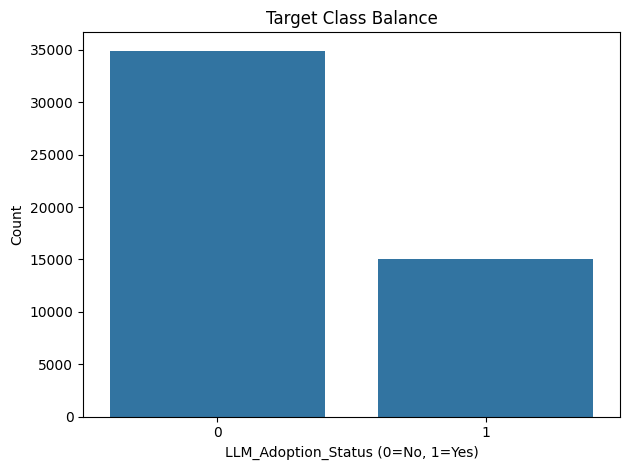

In [117]:
# Class balance — target distribution
counts = df[TARGET].value_counts().sort_index()
print("Class counts:\n", counts)
print("Class proportions:\n", (counts / counts.sum()).round(3))

# Simple bar plot
plt.figure()
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.xlabel("LLM_Adoption_Status (0=No, 1=Yes)")
plt.ylabel("Count")
plt.title("Target Class Balance")
plt.tight_layout()
plt.show()


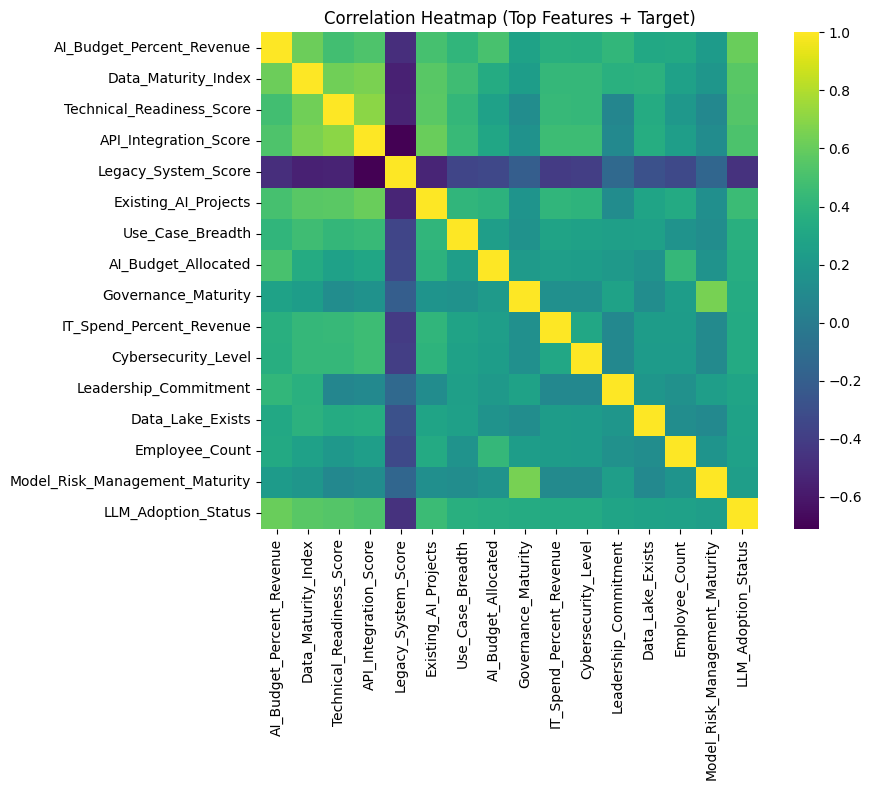

In [118]:
# Heatmap — correlation matrix on top-15 numerics w.r.t. target
H = 15
corr_with_y = df[numeric_cols].corr()[TARGET].drop(labels=[TARGET]).abs().sort_values(ascending=False)
toph_feats = corr_with_y.head(H).index.tolist()
heat_df = df[toph_feats + [TARGET]].copy()

corr_mat = heat_df.corr()  # includes target

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_mat,
    annot=False,
    square=True,
    cmap="viridis"
)
plt.title("Correlation Heatmap (Top Features + Target)")
plt.tight_layout()
plt.show()


In [119]:
# Full Pearson correlation matrix across numerics (incl. target)
corr_mat = df[numeric_cols].corr(method="pearson").round(3)

# Show top-left corner in console
print("Correlation matrix shape:", corr_mat.shape)
display(corr_mat.head(12))

# Save to CSV
corr_mat.to_csv("correlation_matrix.csv", index=True)
print("Saved: correlation_matrix.csv")

Correlation matrix shape: (25, 25)


,Employee_Count,Annual_Revenue_M,IT_Spend_Percent_Revenue,AI_Budget_Allocated,AI_Budget_Percent_Revenue,Budget_Growth_YoY,Has_Dedicated_AI_Team,Technical_Readiness_Score,API_Integration_Score,Data_Lake_Exists,Legacy_System_Score,Data_Maturity_Index,Governance_Framework_Exists,Governance_Maturity,AI_Governance_Committee,Model_Risk_Management_Maturity,Compliance_Incidents_12M,Risk_Culture_Score,Data_Privacy_Compliant,Cybersecurity_Level,Leadership_Commitment,Training_Investment_Per_Employee,Existing_AI_Projects,Use_Case_Breadth,LLM_Adoption_Status
Employee_Count,1.000,0.419,0.229,0.428,0.323,0.083,0.135,0.199,0.243,0.120,-0.333,0.265,0.061,0.237,0.111,0.177,0.010,0.106,0.010,0.219,0.149,0.082,0.331,0.172,0.261
Annual_Revenue_M,0.419,1.000,0.201,0.867,0.282,0.069,0.118,0.174,0.216,0.110,-0.290,0.232,0.051,0.202,0.086,0.151,0.016,0.094,0.010,0.188,0.125,0.079,0.298,0.147,0.228
IT_Spend_Percent_Revenue,0.229,0.201,1.000,0.245,0.366,0.039,0.166,0.436,0.465,0.225,-0.411,0.431,0.034,0.142,0.061,0.104,0.011,0.066,0.005,0.308,0.088,0.106,0.412,0.279,0.330
AI_Budget_Allocated,0.428,0.867,0.245,1.000,0.503,0.115,0.139,0.263,0.305,0.171,-0.341,0.337,0.065,0.218,0.094,0.172,0.002,0.115,0.011,0.232,0.208,0.128,0.389,0.239,0.357
AI_Budget_Percent_Revenue,0.323,0.282,0.366,0.503,1.000,0.210,0.199,0.484,0.519,0.318,-0.486,0.614,0.096,0.275,0.123,0.222,-0.022,0.162,0.011,0.363,0.415,0.236,0.492,0.408,0.609
Budget_Growth_YoY,0.083,0.069,0.039,0.115,0.210,1.000,0.025,0.035,0.044,0.103,-0.070,0.193,0.064,0.141,0.060,0.121,-0.045,0.099,0.007,0.045,0.361,0.131,0.060,0.133,0.137
Has_Dedicated_AI_Team,0.135,0.118,0.166,0.139,0.199,0.025,1.000,0.353,0.238,0.115,-0.219,0.227,0.023,0.079,0.038,0.059,0.005,0.042,-0.006,0.155,0.045,0.061,0.220,0.138,0.209
Technical_Readiness_Score,0.199,0.174,0.436,0.263,0.484,0.035,0.353,1.000,0.700,0.335,-0.548,0.626,0.038,0.119,0.056,0.087,0.003,0.061,0.002,0.426,0.077,0.155,0.563,0.419,0.539
API_Integration_Score,0.243,0.216,0.465,0.305,0.519,0.044,0.238,0.700,1.000,0.349,-0.710,0.658,0.047,0.155,0.069,0.113,0.006,0.073,0.008,0.460,0.092,0.162,0.612,0.440,0.514
Data_Lake_Exists,0.120,0.110,0.225,0.171,0.318,0.103,0.115,0.335,0.349,1.000,-0.289,0.382,0.045,0.119,0.048,0.094,-0.014,0.073,0.004,0.220,0.190,0.135,0.291,0.252,0.277


Saved: correlation_matrix.csv


In [120]:
# Correlation of each numeric feature with the target (sorted desc)
if TARGET not in corr_mat.columns:
    raise ValueError(f"Target '{TARGET}' not found in the numeric correlation matrix.")

corr_with_target = (
    corr_mat[TARGET]
    .drop(labels=[TARGET])       # drop self-correlation
    .sort_values(ascending=False)
    .to_frame("Corr_with_Target")
)

display(corr_with_target.head(20))

,Corr_with_Target
AI_Budget_Percent_Revenue,0.609
Data_Maturity_Index,0.555
Technical_Readiness_Score,0.539
API_Integration_Score,0.514
Existing_AI_Projects,0.458
Use_Case_Breadth,0.369
AI_Budget_Allocated,0.357
Governance_Maturity,0.337
IT_Spend_Percent_Revenue,0.330
Cybersecurity_Level,0.328


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Institution_ID                    50000 non-null  int64  
 1   Institution_Type                  50000 non-null  object 
 2   Country                           50000 non-null  object 
 3   Employee_Count                    50000 non-null  int64  
 4   Annual_Revenue_M                  50000 non-null  float64
 5   IT_Spend_Percent_Revenue          50000 non-null  float64
 6   AI_Budget_Allocated               50000 non-null  float64
 7   AI_Budget_Percent_Revenue         50000 non-null  float64
 8   Budget_Growth_YoY                 50000 non-null  float64
 9   Has_Dedicated_AI_Team             50000 non-null  int64  
 10  Technical_Readiness_Score         50000 non-null  int64  
 11  API_Integration_Score             50000 non-null  int64  
 12  Data

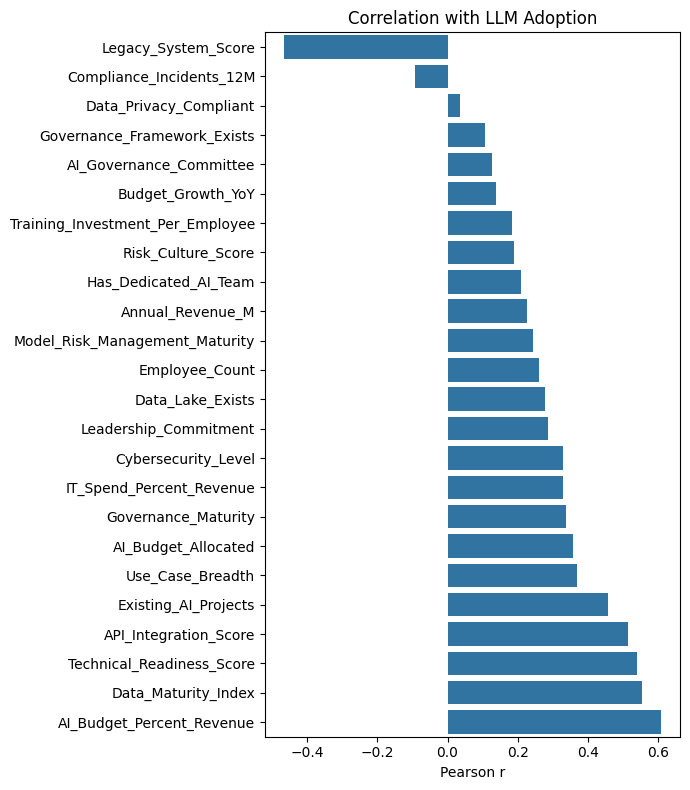

In [122]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
# Supports: RQ1 (which factors matter most)
# Why: Quickly shows strongest linear associations with adoption.

TARGET = "LLM_Adoption_Status"
num_cols = df.select_dtypes(include="number").columns.drop(["Institution_ID"])
corr_with_y = df[num_cols].corr()[TARGET].drop(TARGET).sort_values()

plt.figure(figsize=(7,8))
sns.barplot(x=corr_with_y.values, y=corr_with_y.index, orient="h")
plt.title("Correlation with LLM Adoption")
plt.xlabel("Pearson r")
plt.ylabel("")
plt.tight_layout(); plt.show()


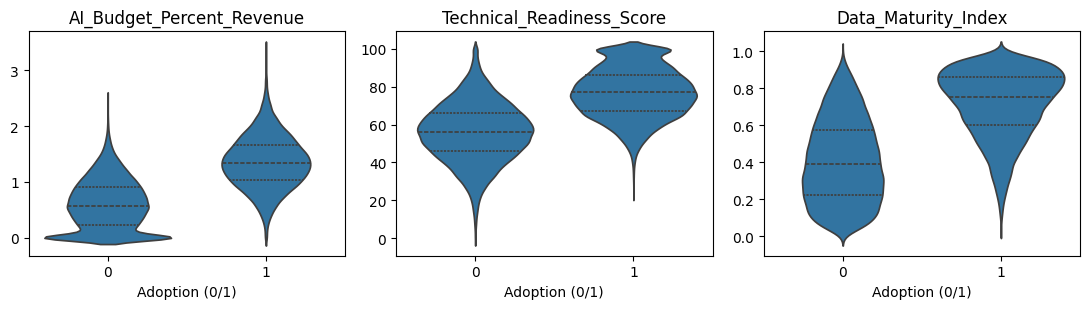

In [123]:
# Supports: H1 (budget %, readiness → higher adoption), RQ1
# Why: Distribution contrast for top drivers.

top_feats = ["AI_Budget_Percent_Revenue","Technical_Readiness_Score","Data_Maturity_Index"]
plt.figure(figsize=(11,3.2))
for i, col in enumerate(top_feats, 1):
    plt.subplot(1,3,i)
    sns.violinplot(data=df, x="LLM_Adoption_Status", y=col, inner="quartile")
    plt.title(col); plt.xlabel("Adoption (0/1)"); plt.ylabel("")
plt.tight_layout(); plt.show()


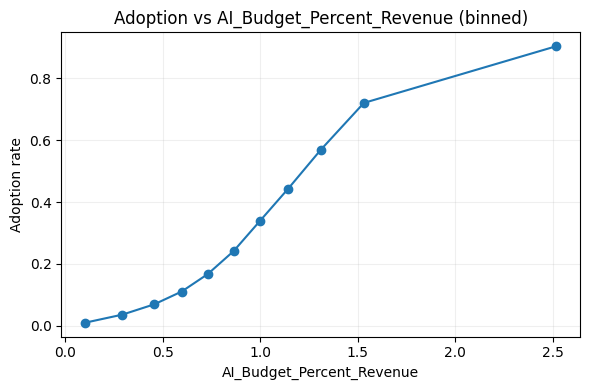

In [124]:
# Supports: H1, practical thresholding for execs
# Why: Interpretable monotonic trend; shows where adoption jumps.

def adoption_vs_binned(feature, bins=10):
    b = pd.qcut(df[feature], q=bins, duplicates="drop")
    tmp = df.groupby(b)["LLM_Adoption_Status"].mean().reset_index()
    tmp["mid"] = tmp[feature].apply(lambda s: s.mid)
    tmp = tmp.sort_values("mid")
    plt.figure(figsize=(6,4))
    plt.plot(tmp["mid"], tmp["LLM_Adoption_Status"], marker="o")
    plt.xlabel(feature); plt.ylabel("Adoption rate")
    plt.title(f"Adoption vs {feature} (binned)")
    plt.grid(alpha=.2); plt.tight_layout(); plt.show()

adoption_vs_binned("AI_Budget_Percent_Revenue", bins=12)


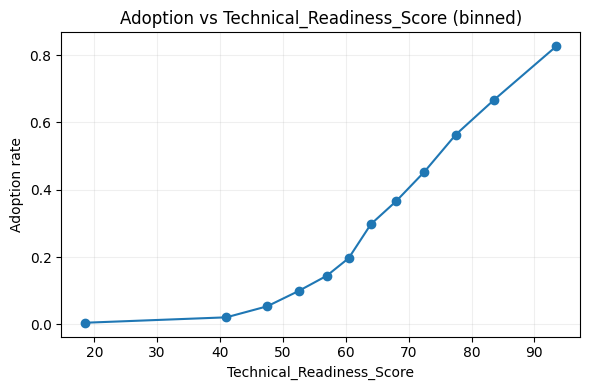

In [125]:
adoption_vs_binned("Technical_Readiness_Score", bins=12)
# Supports: H1/H2 (readiness is key)

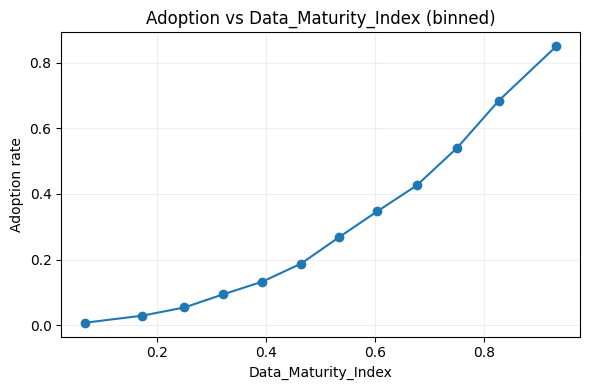

In [126]:
adoption_vs_binned("Data_Maturity_Index", bins=12)
# Supports: RQ1 (data foundations matter)

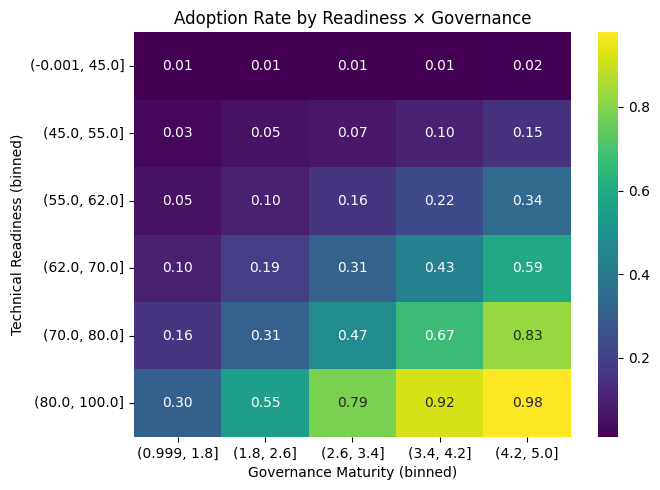

In [127]:
# Supports: H2/H3, RQ2 (interaction)
# Why: Tests the claim that governance moderates readiness.

# Bin both axes
r_bins = pd.qcut(df["Technical_Readiness_Score"], q=6, duplicates="drop")
g_bins = pd.qcut(df["Governance_Maturity"], q=5, duplicates="drop")
pivot = df.groupby([r_bins, g_bins])["LLM_Adoption_Status"].mean().unstack()

plt.figure(figsize=(7,5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title("Adoption Rate by Readiness × Governance")
plt.xlabel("Governance Maturity (binned)"); plt.ylabel("Technical Readiness (binned)")
plt.tight_layout(); plt.show()


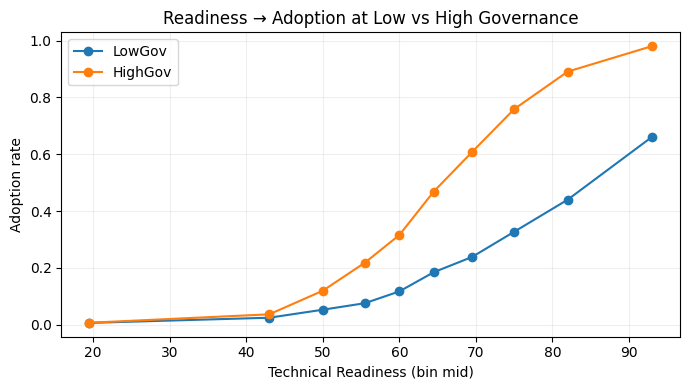

In [128]:
# Supports: H2/H3 (moderation visualized as slope change)

g = pd.qcut(df["Governance_Maturity"], q=2, labels=["LowGov","HighGov"])
r = pd.qcut(df["Technical_Readiness_Score"], q=10, duplicates="drop")

tmp = df.assign(G=g, R=r).groupby(["R","G"])["LLM_Adoption_Status"].mean().reset_index()
# map bin to midpoints
tmp["R_mid"] = tmp["R"].apply(lambda s: s.mid)

plt.figure(figsize=(7,4))
for grp, d in tmp.groupby("G"):
    d = d.sort_values("R_mid")
    plt.plot(d["R_mid"], d["LLM_Adoption_Status"], marker="o", label=grp)
plt.xlabel("Technical Readiness (bin mid)"); plt.ylabel("Adoption rate")
plt.title("Readiness → Adoption at Low vs High Governance")
plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()


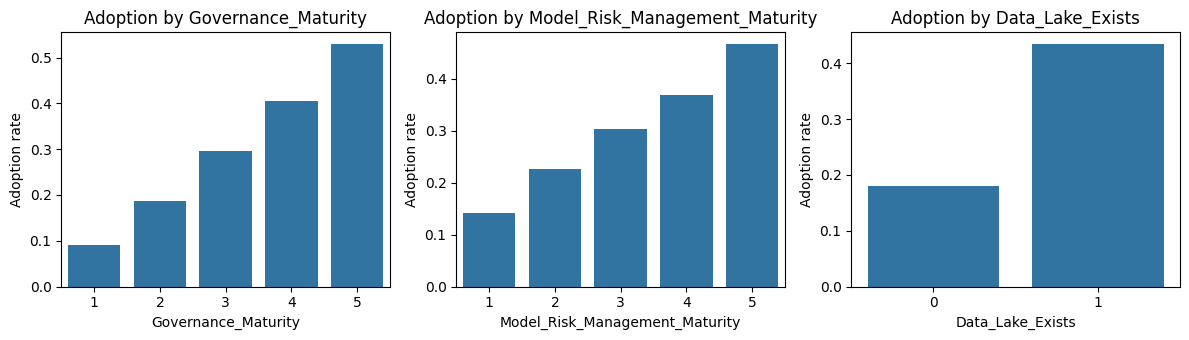

In [129]:
# Supports: RQ1 (organizational levers), comms with leadership

cats = ["Governance_Maturity","Model_Risk_Management_Maturity","Data_Lake_Exists"]
plt.figure(figsize=(12,3.5))
for i, c in enumerate(cats, 1):
    plt.subplot(1, len(cats), i)
    sns.barplot(
        data=df, x=c, y="LLM_Adoption_Status",
        estimator="mean", errorbar=None
    )
    plt.title(f"Adoption by {c}"); plt.ylabel("Adoption rate")
plt.tight_layout(); plt.show()


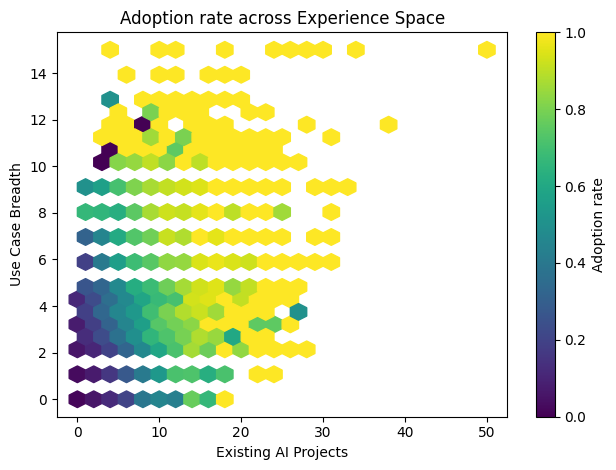

In [130]:
# Why: Both correlate with adoption; this shows “experience space” visually.
# Supports: RQ1 (internal experience dimension).
plt.hexbin(df["Existing_AI_Projects"], df["Use_Case_Breadth"],
           gridsize=25, C=df["LLM_Adoption_Status"], reduce_C_function=np.mean)
plt.colorbar(label="Adoption rate")
plt.xlabel("Existing AI Projects"); plt.ylabel("Use Case Breadth")
plt.title("Adoption rate across Experience Space")
plt.tight_layout(); plt.show()
